# ΔE double against c(q) — RT

The tail notebook assumes a decomposition:

$$\Delta E_{\text{double}} \;=\; \sum_{q \notin \{p_1,p_2\}} c(q) \;+\; \big[J(p_1,p_2,wt_1,wt_2) - J(p_1,p_2,mt_1,mt_2)\big]$$

and then treats sd of c(q) as the leverage position q has over ΔE double. This notebook is the
check behind that: that ΔE double really does move with c(q), one for one and without exception.

Three steps, each stronger than the last and each verified against an **independent** ΔE double —
recomputed from site energies with the mutated sequences, never from the decomposition itself:

1. **the identity closes** — the per-position terms plus the direct coupling reproduce ΔE double
   for every RT pair and every sequence in the alignment;
2. **the controlled experiment** — force position q through all four residues in every sequence
   and recompute. ΔE double shifts by exactly the shift in c(q): slope 1, no scatter, monotone by
   construction rather than by luck;
3. **the observational version** — the alignment as it actually is. Here monotonicity is a claim
   that can fail, because the residue at q covaries with the rest of the background. How often it
   fails, and where, is measured rather than assumed.

RT throughout, pairs from `ms0_5/RT/data/top_20_DRM.txt`.

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"
PROTEIN, MIN_POS, MAX_POS = 'RT', 39, 226
L = MAX_POS - MIN_POS + 1
POSITIONS = np.arange(MIN_POS, MAX_POS + 1)

ALL_SEQ = functions.read_seq(str(data_root / "RT" / "data" / "rt.reduce4.seq"))
REDUX = functions.get_redu_dict(str(data_root / "RT" / "data" / "rt.reduce4.redux"), 0)


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    Ln = max_position - min_position + 1
    Jm = np.zeros((Ln, Ln, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(Ln, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


J = build_J_matrix(str(data_root / "RT" / "data" / "J_RT.npy"), MIN_POS, MAX_POS)

_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def codes_from_seqs(seq_list):
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * L, "all sequences must span exactly MIN_POS..MAX_POS"
    return _AA_CODE[raw.reshape(N, L)]


def onehot_from_codes(codes):
    N = codes.shape[0]
    oh = np.zeros((N * L, 5), dtype=np.float32)
    oh[np.arange(N * L), codes.ravel()] = 1.0
    return oh.reshape(N, L * 5)


CODES = codes_from_seqs(ALL_SEQ)
ONEHOT = onehot_from_codes(CODES)
N = CODES.shape[0]
print(f"RT: {N:,} sequences, {L} positions ({MIN_POS}-{MAX_POS})")

RT: 19,194 sequences, 188 positions (39-226)


In [2]:
# ---------------------------------------------------------------------------
# TWO ROUTES TO dE double, kept deliberately separate.
#
#   de_double_energy   the definition. Site energies against the rest of the sequence, plus the
#                      p1-p2 coupling, evaluated at (wt1,wt2) and at (mt1,mt2). Nothing in it
#                      knows about c(q).
#
#   cvals              the (L, 5) table of values c(q) can take, from J alone.
#
# Everything below compares the first against predictions made with the second. Whenever a
# sequence is modified, de_double_energy is run again on the modified sequence -- the c(q)
# arithmetic is never used to produce the thing it is being tested against.
# ---------------------------------------------------------------------------
def reduced_idx(pair):
    """'M41L-T215Y' -> (p1, p2, wt1, mt1, wt2, mt2) as 0-based position / residue indices."""
    a, b = functions.split_pairs(pair)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(REDUX, a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(REDUX, b))
    return (pos1 - MIN_POS, pos2 - MIN_POS, "ABCD".index(wt1), "ABCD".index(mt1),
            "ABCD".index(wt2), "ABCD".index(mt2))


def _site_energies(onehot, p, excluded):
    A = J[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def de_double_energy(onehot, idx):
    """dE double per sequence, straight from the energies."""
    p1, p2, wt1, mt1, wt2, mt2 = idx
    S1 = _site_energies(onehot, p1, (p1, p2))
    S2 = _site_energies(onehot, p2, (p1, p2))
    J12 = J[p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    return M[:, wt1, wt2] - M[:, mt1, mt2]


def cvals(pair):
    """(L, 5) values c(q) can take -- one column per residue -- and the direct term."""
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(pair)
    CV = ((J[p1, :, wt1, :] - J[p1, :, mt1, :])
          + (J[p2, :, wt2, :] - J[p2, :, mt2, :])).astype(np.float64)
    CV[[p1, p2]] = 0.0
    direct = float(J[p1, p2, wt1, wt2] - J[p1, p2, mt1, mt2])
    return CV, direct


PAIRS, SKIPPED = [], []
for line in (data_root / "RT" / "data" / "top_20_DRM.txt").read_text().splitlines():
    line = line.strip()
    if not line:
        continue
    pair = '-'.join(tok.strip() for tok in line.split('-'))
    try:
        p1, p2, *_ = reduced_idx(pair)
        assert 0 <= p1 < L and 0 <= p2 < L and p1 != p2
        PAIRS.append(pair)
    except Exception as exc:
        SKIPPED.append((pair, str(exc)))

DE = {pair: de_double_energy(ONEHOT, reduced_idx(pair)) for pair in PAIRS}
CV = {pair: cvals(pair) for pair in PAIRS}
print(f"{len(PAIRS)} RT pairs" + (f", skipped {SKIPPED}" if SKIPPED else ""))

40 RT pairs


In [3]:
# =============================================================================
# STEP 1 -- the identity closes.
#
# For every pair, add up the per-position terms the alignment actually realizes, add the direct
# p1-p2 coupling, and compare against the energy route sequence by sequence. If the split is
# real the difference is float noise; if it is a convenient approximation, it is not.
# =============================================================================
rows = []
for pair in PAIRS:
    C, direct = CV[pair]
    rebuilt = C[np.arange(L)[None, :], CODES].sum(axis=1) + direct
    diff = np.abs(rebuilt - DE[pair])
    rows.append({'pair': pair, 'max |difference|': diff.max(),
                 'mean |difference|': diff.mean(),
                 'sd(dE double)': DE[pair].std(),
                 'relative to sd': diff.max() / DE[pair].std()})

IDENTITY = pd.DataFrame(rows)
print(f"worst case over {len(PAIRS)} pairs x {N:,} sequences: "
      f"{IDENTITY['max |difference|'].max():.2e}  "
      f"({IDENTITY['relative to sd'].max():.1e} of one sd of dE double)")
IDENTITY.sort_values('max |difference|', ascending=False).head(5)

worst case over 40 pairs x 19,194 sequences: 4.11e-06  (2.5e-06 of one sd of dE double)


,pair,max |difference|,mean |difference|,sd(dE double),relative to sd
29,V108I-H221Y,0.000004,9.644466e-07,1.674313,0.000002
32,K101E-E138A,0.000004,1.372238e-06,1.703779,0.000002
14,D67N-K70R,0.000004,1.017808e-06,3.629114,0.000001
35,V108I-V189I,0.000004,1.101001e-06,1.664978,0.000002
0,F116Y-Q151M,0.000004,7.635749e-07,2.756263,0.000001


In [4]:
# =============================================================================
# STEP 2 -- the controlled experiment.
#
# Take one pair and one background position q. Write residue a into position q of EVERY sequence
# in the alignment, leaving the rest of each sequence alone, and recompute dE double from the
# energies. Repeat for all four residues.
#
# The prediction from the decomposition is that the only thing that changes is the q term:
#
#     dE double(s with a at q) - dE double(s with b at q)  =  c(q,a) - c(q,b)
#
# for every sequence s, with no dependence on what the rest of s looks like. That is a strong
# statement -- one number per residue pair, holding across 19,194 different backgrounds -- and
# it is what makes "dE double rises with c(q)" exact rather than statistical.
# =============================================================================
def swap_experiment(pair, q):
    """dE double recomputed from energies with residue a forced at q, for a = A..D."""
    idx = reduced_idx(pair)
    out = {}
    for a in range(4):
        codes_a = CODES.copy()
        codes_a[:, q] = a
        out[a] = de_double_energy(onehot_from_codes(codes_a), idx)
    return out


EX_PAIR, EX_Q = 'L210W-T215Y', 41 - MIN_POS          # the strongest cell in the RT upper tail
SWAP = swap_experiment(EX_PAIR, EX_Q)
C_EX, _ = CV[EX_PAIR]

print(f"{EX_PAIR}, forcing position {POSITIONS[EX_Q]} through A, B, C, D "
      f"in all {N:,} sequences\n")
print(f"{'residue':<9}{'c(q)':>9}{'mean dE double':>17}{'sd across backgrounds':>24}")
for a in range(4):
    print(f"{'ABCD'[a]:<9}{C_EX[EX_Q, a]:9.4f}{SWAP[a].mean():17.4f}{SWAP[a].std():24.4f}")

print("\nDifferences between residues, sequence by sequence:")
worst = 0.0
for a in range(4):
    for b in range(a + 1, 4):
        d = SWAP[a] - SWAP[b]
        pred = C_EX[EX_Q, a] - C_EX[EX_Q, b]
        worst = max(worst, np.abs(d - pred).max())
        print(f"  {'ABCD'[a]} - {'ABCD'[b]}:  observed {d.min():+.4f} to {d.max():+.4f}"
              f"   predicted {pred:+.4f}   max |error| {np.abs(d - pred).max():.2e}")
print(f"\nworst error anywhere: {worst:.2e}")
assert worst < 1e-3
print("every sequence moves by the same amount -- the shift in c(q), and nothing else")

L210W-T215Y, forcing position 41 through A, B, C, D in all 19,194 sequences

residue       c(q)   mean dE double   sd across backgrounds
A          -0.6716          -1.0869                  4.3949
B           0.1514          -0.2640                  4.3949
C           2.7098           2.2945                  4.3949
D          -2.2890          -2.7043                  4.3949

Differences between residues, sequence by sequence:
  A - B:  observed -0.8230 to -0.8230   predicted -0.8230   max |error| 2.52e-06
  A - C:  observed -3.3815 to -3.3815   predicted -3.3815   max |error| 2.62e-06
  A - D:  observed +1.6173 to +1.6173   predicted +1.6173   max |error| 2.86e-06
  B - C:  observed -2.5585 to -2.5585   predicted -2.5585   max |error| 2.97e-06
  B - D:  observed +2.4403 to +2.4403   predicted +2.4403   max |error| 3.20e-06
  C - D:  observed +4.9988 to +4.9988   predicted +4.9988   max |error| 3.04e-06

worst error anywhere: 3.20e-06
every sequence moves by the same amount -- the shift

In [5]:
# =============================================================================
# The same experiment run over many (pair, q) cells, in two groups: the strongest background
# positions in RT and the weakest. For each cell, regress the recomputed dE double on c(q)
# across the 4 x N points.
#
# A slope of exactly 1 with R^2 exactly 1 says dE double is c(q) plus something that does not
# depend on q at all. The two groups differ only in the SPREAD of c(q) -- how far apart its four
# values are -- which is what sd of c(q) measured in the tail notebook.
# =============================================================================
def sd_of_c(pair):
    F = np.stack([(CODES == a).mean(axis=0) for a in range(5)], axis=1)
    C, _ = CV[pair]
    mu = (F * C).sum(axis=1)
    return np.sqrt(np.maximum((F * C ** 2).sum(axis=1) - mu ** 2, 0.0))


SD_Q = {pair: sd_of_c(pair) for pair in PAIRS}
SD_ALL = np.stack([SD_Q[p] for p in PAIRS])
SELF = np.zeros_like(SD_ALL, dtype=bool)
for i, pair in enumerate(PAIRS):
    p1, p2, *_ = reduced_idx(pair)
    SELF[i, [p1, p2]] = True
TESTABLE = ~SELF

flat = np.where(TESTABLE, SD_ALL, np.nan).ravel()
order = np.argsort(flat)
order = order[np.isfinite(flat[order])]
STRONG = [(PAIRS[r // L], r % L) for r in order[::-1][:6]]
WEAK = [(PAIRS[r // L], r % L) for r in order[:6]]

rows = []
for group, cells in (('strongest', STRONG), ('weakest', WEAK)):
    for pair, q in cells:
        sw = swap_experiment(pair, q)
        c_at, _ = CV[pair]
        x = np.repeat(c_at[q, :4], N)
        y = np.concatenate([sw[a] for a in range(4)])
        slope, intercept = np.polyfit(x, y, 1)
        resid = y - (slope * x + intercept)
        rows.append({'group': group, 'pair': pair, 'q': POSITIONS[q],
                     'sd of c(q)': SD_Q[pair][q],
                     'spread of c(q) (max-min)': c_at[q, :4].max() - c_at[q, :4].min(),
                     'slope': slope,
                     'R^2': 1 - resid.var() / y.var(),
                     'max |residual| from slope 1':
                         np.abs(y - (x + (y - x).mean())).max(),
                     'range of mean dE double across residues':
                         max(sw[a].mean() for a in range(4)) - min(sw[a].mean() for a in range(4))})

SWAP_TABLE = pd.DataFrame(rows)
print("regression of the recomputed dE double on c(q), 4 x "
      f"{N:,} points per cell:\n")
SWAP_TABLE.round(6)

regression of the recomputed dE double on c(q), 4 x 19,194 points per cell:



,group,pair,q,sd of c(q),spread of c(q) (max-min),slope,R^2,max |residual| from slope 1,range of mean dE double across residues
0,strongest,L210W-T215Y,41,2.447781,4.998805,1.000000,0.144541,16.938647,4.998805
1,strongest,K70R-K219Q,67,2.342267,4.935668,1.000000,0.336752,12.996424,4.935670
2,strongest,K70R-K219E,67,2.201582,4.587466,1.000000,0.455394,10.035088,4.587468
3,strongest,D67N-K70R,219,2.140967,5.449897,1.000000,0.609791,9.927710,5.449897
4,strongest,D67N-K219E,70,1.989873,4.977503,1.000000,0.346414,11.163917,4.977503
5,strongest,D67N-K219Q,70,1.974766,4.925183,1.000000,0.354056,14.759168,4.925184
6,weakest,K103S-G190A,95,0.000104,0.015268,1.000007,0.000015,7.874790,0.015268
7,weakest,K101P-K103S,81,0.000131,0.013234,1.000004,0.000008,8.343642,0.013234
8,weakest,K101E-E138K,55,0.000188,0.029704,1.000003,0.000035,7.690765,0.029704
9,weakest,K101E-E138A,55,0.000192,0.025352,1.000006,0.000030,7.023367,0.025352


In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'
DEEP, PALE, COOL_DEEP, COOL = '#6d0f18', '#f4a582', '#175d92', '#9ecae1'

plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'savefig.facecolor': SURFACE, 'font.size': 9, 'legend.frameon': False,
                     'axes.edgecolor': BASE, 'axes.linewidth': 0.7})


def bare(ax, grid='y'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(BASE)
    ax.tick_params(length=0, labelsize=8, colors=MUTED)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


print('style ready')

style ready


saved de_double_vs_cq_forced_RT.png / .pdf


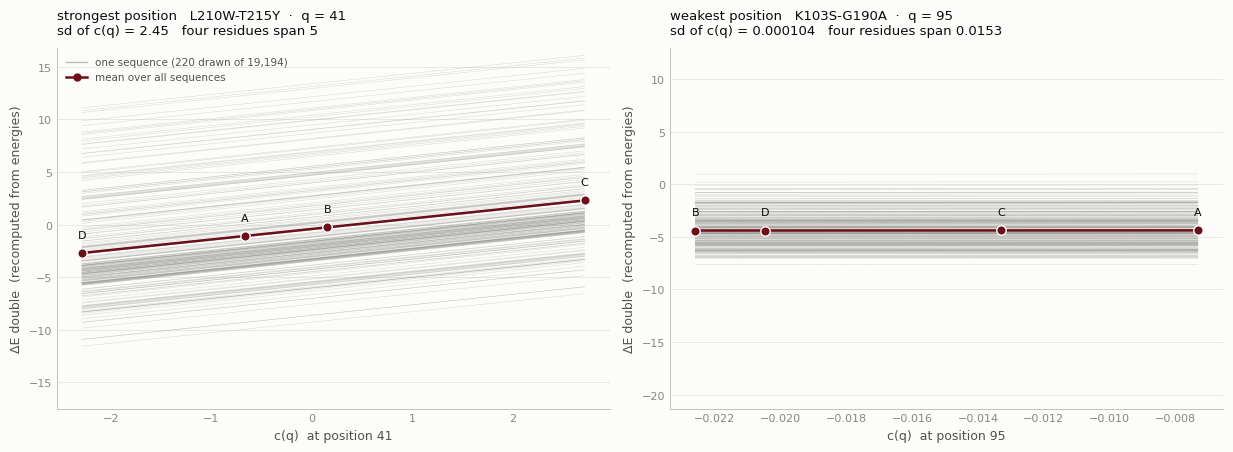

In [7]:
# =============================================================================
# FIGURE 1 -- the controlled experiment, drawn.
#
# Each thin line is ONE sequence from the alignment, carried through all four residues at q with
# everything else about it held fixed; the dot at each end of the line's four points is where
# that background lands. Every line has the same shape because every line has slope exactly 1 --
# they sit at different heights because the rest of the background differs, and that offset is
# what c(q) is not responsible for.
#
# LEFT is the strongest background position in RT, RIGHT one of the weakest, drawn on the same
# y span. Both are perfectly monotone in c(q). Only the x span differs, and that is the whole
# content of sd of c(q): a weak position is one whose four c(q) values sit on top of each other,
# so being monotone in it moves dE double nowhere.
# =============================================================================
SHOW = [('strongest position', *STRONG[0]), ('weakest position', *WEAK[0])]
rng = np.random.default_rng(0)
sample = rng.choice(N, 220, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
span = None
for ax, (label, pair, q) in zip(axes, SHOW):
    sw = swap_experiment(pair, q)
    c_at, _ = CV[pair]
    x = c_at[q, :4]
    Y = np.stack([sw[a][sample] for a in range(4)], axis=1)          # (sample, 4)

    o = np.argsort(x)
    for k in range(Y.shape[0]):
        ax.plot(x[o], Y[k][o], color=MUTED, lw=0.35, alpha=0.30, zorder=2)
    means = np.array([sw[a].mean() for a in range(4)])
    ax.plot(x[o], means[o], color=DEEP, lw=1.8, zorder=5)
    ax.scatter(x[o], means[o], s=46, color=DEEP, edgecolor=SURFACE, linewidth=1.0, zorder=6)
    for a in range(4):
        ax.annotate('ABCD'[a], (x[a], means[a]), textcoords='offset points', xytext=(0, 11),
                    ha='center', fontsize=8, color=INK)

    if span is None:
        span = Y.max() - Y.min()
    ax.set_ylim(Y.mean() - span * 0.62, Y.mean() + span * 0.62)
    ax.set_xlabel(f'c(q)  at position {POSITIONS[q]}', color=INK2)
    ax.set_ylabel('ΔE double  (recomputed from energies)', color=INK2)
    ax.set_title(f'{label}   {pair}  ·  q = {POSITIONS[q]}\n'
                 f'sd of c(q) = {SD_Q[pair][q]:.3g}   '
                 f'four residues span {x.max() - x.min():.3g}',
                 fontsize=9.5, color=INK, loc='left', pad=10)
    bare(ax)

axes[0].legend(handles=[
    Line2D([], [], color=MUTED, lw=0.9, alpha=0.6, label=f'one sequence ({len(sample)} drawn '
                                                         f'of {N:,})'),
    Line2D([], [], color=DEEP, lw=1.8, marker='o', markersize=5, label='mean over all sequences'),
], fontsize=7.5, labelcolor=INK2, loc='upper left')

fig.tight_layout()
fig.savefig('de_double_vs_cq_forced_RT.png', dpi=400, bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
fig.savefig('de_double_vs_cq_forced_RT.pdf', bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
print('saved de_double_vs_cq_forced_RT.png / .pdf')
plt.show()

In [8]:
# =============================================================================
# STEP 3 -- the alignment as it is.
#
# Step 2 held the rest of the sequence fixed, which is what made the relation exact. Real
# sequences do not cooperate: the residue at q covaries with the residues everywhere else, so the
# mean dE double of the sequences that HAPPEN to carry residue a at q is
#
#     c(q,a)  +  E[ everything else | residue a at q ]
#
# and the second term need not be flat. Monotonicity is therefore a claim about the alignment
# here, not an identity, and it can fail. This measures how often it does.
#
# For every (pair, q) cell: order the observed residues by c(q), and ask whether the observed
# mean dE double is ordered the same way.
# =============================================================================
IND = [np.asarray(CODES == a, dtype=np.float64) for a in range(4)]
COUNTS = np.stack([I.sum(axis=0) for I in IND])                      # (4, L)

rows = []
for pair in PAIRS:
    de = DE[pair]
    C, _ = CV[pair]
    means = np.stack([(de @ IND[a]) / np.maximum(COUNTS[a], 1) for a in range(4)])   # (4, L)
    p1, p2, *_ = reduced_idx(pair)
    for q in range(L):
        if q in (p1, p2):
            continue
        seen = np.where(COUNTS[:, q] > 0)[0]
        if seen.size < 2:
            continue
        x, y = C[q, seen], means[seen, q]
        o = np.argsort(x)
        rows.append({
            'pair': pair, 'q': POSITIONS[q], 'sd of c(q)': SD_Q[pair][q],
            'residues seen': seen.size,
            'rarest residue count': int(COUNTS[seen, q].min()),
            'monotone in the alignment': bool(np.all(np.diff(y[o]) > 0)),
            'observed spread of mean dE double': float(y.max() - y.min()),
            'spread predicted by c(q)': float(x.max() - x.min()),
            # correlation of c(q) with dE double across the alignment
            'r with dE double': float(np.corrcoef(C[q, CODES[:, q]], de)[0, 1]),
        })

OBS = pd.DataFrame(rows)
OBS['variance share'] = OBS['r with dE double'] ** 2

# Two things are needed before the monotone share means anything.
#
# First a baseline: with k residues observed, a cell whose means were in random order would come
# out monotone 1/k! of the time -- 1/24 with all four.
#
# Second a size: c(q) only claims to move dE double by its own spread, and most cells claim
# almost nothing. A cell where c(q) spans 0.01 while the pair's dE double has an sd of 2 is not
# evidence against the relation when its means come out shuffled -- there is nothing there to
# order. So the share is also cut by how large the claim is, in units of the pair's own spread.
SD_DE = dict(zip(PAIRS, [DE[p].std() for p in PAIRS]))
OBS['sd(dE double) of the pair'] = OBS['pair'].map(SD_DE)
OBS['claim size'] = OBS['spread predicted by c(q)'] / OBS['sd(dE double) of the pair']
OBS['monotone by chance'] = 1.0 / OBS['residues seen'].map(lambda k: np.math.factorial(k)
                                                           if hasattr(np, 'math') else
                                                           float(np.prod(np.arange(1, k + 1))))

by_decile = OBS.assign(
    band=pd.qcut(OBS['sd of c(q)'], 10, labels=[f'{i + 1}' for i in range(10)]))
SUMMARY = (by_decile.groupby('band', observed=True)
           .agg(**{'cells': ('pair', 'size'),
                   'median sd of c(q)': ('sd of c(q)', 'median'),
                   'monotone in the alignment': ('monotone in the alignment', 'mean'),
                   'median r with dE double': ('r with dE double', 'median'),
                   'median variance share': ('variance share', 'median')})
           .reset_index())

BANDS = [(0.0, 0.05, 'under 0.05 sd -- nothing to order'),
         (0.05, 0.25, '0.05 to 0.25 sd'),
         (0.25, 1.0, '0.25 to 1 sd'),
         (1.0, np.inf, 'over 1 sd -- c(q) claims a visible shift')]
CLAIM = pd.DataFrame([
    {'claim size (c(q) spread / sd of the pair’s dE double)': name,
     'cells': int(m.sum()),
     'monotone in the alignment': OBS.loc[m, 'monotone in the alignment'].mean(),
     'monotone by chance': OBS.loc[m, 'monotone by chance'].mean(),
     'median r with dE double': OBS.loc[m, 'r with dE double'].median(),
     'median sd of c(q)': OBS.loc[m, 'sd of c(q)'].median()}
    for lo, hi, name in BANDS
    for m in [(OBS['claim size'] >= lo) & (OBS['claim size'] < hi)]])

print(f"{len(OBS):,} (pair, q) cells with at least two residues observed")
print(f"monotone in the alignment: {OBS['monotone in the alignment'].mean():.1%} overall, "
      f"against {OBS['monotone by chance'].mean():.1%} if the means were ordered at random")
for lo, name in ((OBS['sd of c(q)'] > np.quantile(OBS['sd of c(q)'], 0.975), 'upper 2.5% tail'),
                 (OBS['sd of c(q)'] < np.quantile(OBS['sd of c(q)'], 0.025), 'lower 2.5% tail')):
    sub = OBS[lo]
    print(f"   {name}: {sub['monotone in the alignment'].mean():.1%} of {len(sub)} cells "
          f"(chance {sub['monotone by chance'].mean():.1%}), "
          f"median r = {sub['r with dE double'].median():.3f}")
display(CLAIM.round(4))
SUMMARY.round(4)

7,440 (pair, q) cells with at least two residues observed
monotone in the alignment: 21.3% overall, against 4.6% if the means were ordered at random
   upper 2.5% tail: 54.8% of 186 cells (chance 4.2%), median r = 0.458
   lower 2.5% tail: 12.4% of 186 cells (chance 8.1%), median r = 0.001


,claim size (c(q) spread / sd of the pair’s dE double),cells,monotone in the alignment,monotone by chance,median r with dE double,median sd of c(q)
0,under 0.05 sd -- nothing to order,771,0.1154,0.0614,0.0037,0.0017
1,0.05 to 0.25 sd,4978,0.1826,0.0446,0.0134,0.0109
2,0.25 to 1 sd,1606,0.3325,0.0417,0.0659,0.0920
3,over 1 sd -- c(q) claims a visible shift,85,0.6235,0.0417,0.4422,0.5062


,band,cells,median sd of c(q),monotone in the alignment,median r with dE double,median variance share
0,1,744,0.0014,0.1290,0.0034,0.0000
1,2,744,0.0028,0.1304,0.0062,0.0000
2,3,744,0.0045,0.1841,0.0085,0.0001
3,4,744,0.0070,0.1882,0.0108,0.0001
4,5,744,0.0113,0.2003,0.0149,0.0003
5,6,744,0.0194,0.2124,0.0195,0.0005
6,7,744,0.0346,0.2070,0.0280,0.0011
7,8,744,0.0605,0.2379,0.0463,0.0027
8,9,744,0.1089,0.2661,0.0778,0.0073
9,10,744,0.2489,0.3750,0.2141,0.0459


saved de_double_vs_cq_observed_RT.png / .pdf


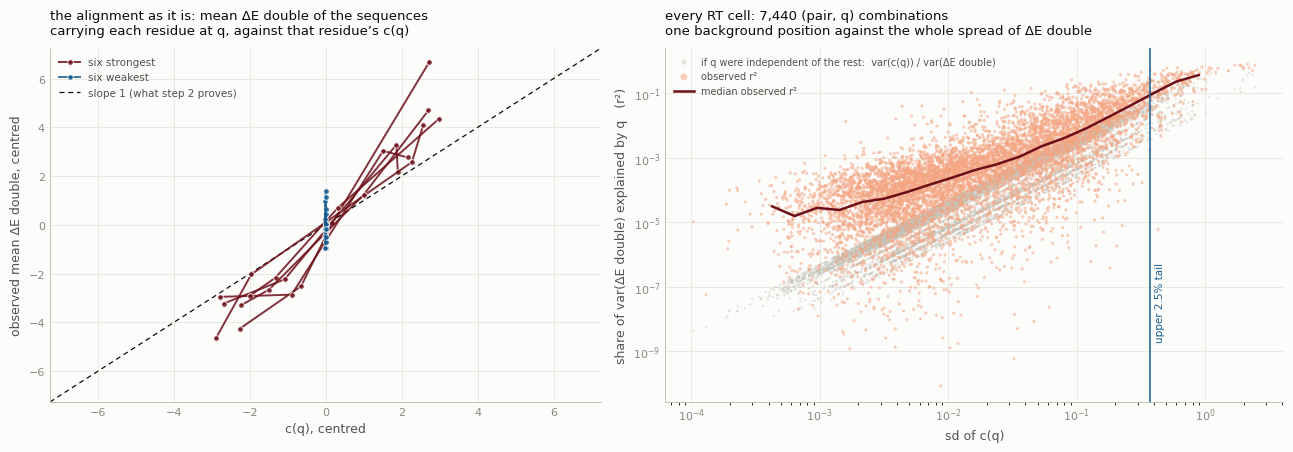

In [9]:
# =============================================================================
# FIGURE 2 -- monotonicity where it is claimed, and where it stops meaning anything.
#
# LEFT: the alignment version of figure 1. One line per (pair, q) cell, its observed mean dE
# double against c(q), centred on its own mean so cells with different offsets can be compared.
# The six strongest positions rise steeply and in order; the six weakest are flat lines --
# their c(q) values are so close together that whether the means happen to be ordered is noise.
#
# RIGHT: every cell in RT at once. How much of the variance of dE double a single background
# position accounts for, against its sd of c(q). Rising across four decades, which is the claim
# sd of c(q) was standing in for all along.
#
# The grey cloud underneath is what each cell WOULD explain if q were independent of the rest of
# the background: var(c(q)) / var(dE double), the square law the decomposition predicts. It is a
# cloud rather than a line because each pair has its own var(dE double). Orange above grey at the
# same x means the residue at q travels with residues elsewhere that push dE double the same way;
# below means they partly cancel.
# =============================================================================
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.0, 4.6),
                               gridspec_kw={'width_ratios': [1, 1.12]})

# -- LEFT ----------------------------------------------------------------------------------
for group, cells, colour in (('six strongest', STRONG, DEEP), ('six weakest', WEAK, COOL_DEEP)):
    for k, (pair, q) in enumerate(cells):
        de = DE[pair]
        C, _ = CV[pair]
        seen = np.where(COUNTS[:, q] > 0)[0]
        x = C[q, seen]
        y = np.array([de[CODES[:, q] == a].mean() for a in seen])
        o = np.argsort(x)
        axL.plot(x[o] - x.mean(), y[o] - y.mean(), color=colour, lw=1.4, marker='o',
                 markersize=4, markeredgecolor=SURFACE, markeredgewidth=0.7, alpha=0.85,
                 zorder=3, label=group if k == 0 else None)

lim = max(abs(np.array(axL.get_xlim())).max(), abs(np.array(axL.get_ylim())).max())
axL.plot([-lim, lim], [-lim, lim], color=INK, lw=0.9, ls=(0, (4, 3)), zorder=2,
         label='slope 1 (what step 2 proves)')
axL.set_xlim(-lim, lim)
axL.set_ylim(-lim, lim)
axL.set_xlabel('c(q), centred', color=INK2)
axL.set_ylabel('observed mean ΔE double, centred', color=INK2)
axL.set_title('the alignment as it is: mean ΔE double of the sequences\n'
              'carrying each residue at q, against that residue’s c(q)',
              fontsize=9.5, color=INK, loc='left', pad=10)
bare(axL, grid='both')
axL.legend(fontsize=7.5, labelcolor=INK2, loc='upper left')

# -- RIGHT ---------------------------------------------------------------------------------
pair_sd = OBS['sd(dE double) of the pair'].to_numpy()
pred = (OBS['sd of c(q)'].to_numpy() / pair_sd) ** 2

x_sd = OBS['sd of c(q)'].to_numpy()
axR.scatter(x_sd, pred, s=3, color=BASE, edgecolor='none', alpha=0.40, zorder=2,
            label='if q were independent of the rest:  var(c(q)) / var(ΔE double)')
axR.scatter(x_sd, OBS['variance share'], s=5, color=PALE, edgecolor='none', alpha=0.55,
            zorder=3, label='observed r²')

# median observed share in log-spaced bins of sd of c(q)
edges = np.logspace(np.log10(x_sd.min()), np.log10(x_sd.max()), 26)
mid, med = [], []
for a, b in zip(edges[:-1], edges[1:]):
    m = (x_sd >= a) & (x_sd < b)
    if m.sum() >= 20:
        mid.append(np.sqrt(a * b))
        med.append(np.median(OBS['variance share'].to_numpy()[m]))
axR.plot(mid, med, color=DEEP, lw=1.8, zorder=4, label='median observed r²')
tail = np.quantile(OBS['sd of c(q)'], 0.975)
axR.axvline(tail, color=COOL_DEEP, lw=1.1, zorder=5)
axR.text(tail * 1.08, 2e-9, 'upper 2.5% tail', fontsize=7.5, color=COOL_DEEP, rotation=90,
         va='bottom')
axR.set_xscale('log')
axR.set_yscale('log')
axR.set_xlabel('sd of c(q)', color=INK2)
axR.set_ylabel('share of var(ΔE double) explained by q   (r²)', color=INK2)
axR.set_title(f'every RT cell: {len(OBS):,} (pair, q) combinations\n'
              'one background position against the whole spread of ΔE double',
              fontsize=9.5, color=INK, loc='left', pad=10)
bare(axR, grid='both')
axR.legend(fontsize=7, labelcolor=INK2, loc='upper left', markerscale=2.2)

fig.tight_layout()
fig.savefig('de_double_vs_cq_observed_RT.png', dpi=400, bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
fig.savefig('de_double_vs_cq_observed_RT.pdf', bbox_inches='tight', pad_inches=0.03,
            facecolor=SURFACE)
print('saved de_double_vs_cq_observed_RT.png / .pdf')
plt.show()

In [10]:
# =============================================================================
# Where the alignment version fails, and why.
#
# A cell whose observed means are out of order is one where the residue at q travels with the
# rest of the background: the sequences carrying the high-c(q) residue also carry residues
# elsewhere that pull dE double the other way. The table sorts the failures by how much c(q) says
# they should have moved -- the further down the list, the smaller the claim that was broken.
# =============================================================================
fails = OBS[~OBS['monotone in the alignment']].copy()
fails = fails.sort_values('spread predicted by c(q)', ascending=False)

print(f"{len(fails):,} of {len(OBS):,} cells ({len(fails) / len(OBS):.1%}) are not monotone "
      f"in the alignment")
print(f"of those, {int((fails['claim size'] < 0.05).sum()):,} claimed a shift smaller than "
      f"1/20th of their pair's own sd -- nothing to detect")
print(f"largest c(q) spread among the failures: {fails['spread predicted by c(q)'].max():.3f}"
      f"   (largest anywhere: {OBS['spread predicted by c(q)'].max():.3f})")

IDENTITY.to_csv('de_double_vs_cq_identity_RT.csv', index=False)
SWAP_TABLE.to_csv('de_double_vs_cq_forced_slopes_RT.csv', index=False)
OBS.to_csv('de_double_vs_cq_observed_cells_RT.csv', index=False)
SUMMARY.to_csv('de_double_vs_cq_by_sd_decile_RT.csv', index=False)
CLAIM.to_csv('de_double_vs_cq_by_claim_size_RT.csv', index=False)
fails.to_csv('de_double_vs_cq_non_monotone_cells_RT.csv', index=False)
print('\nsaved de_double_vs_cq_identity_RT.csv, de_double_vs_cq_forced_slopes_RT.csv,\n'
      '      de_double_vs_cq_observed_cells_RT.csv, de_double_vs_cq_by_sd_decile_RT.csv,\n'
      '      de_double_vs_cq_by_claim_size_RT.csv,\n'
      '      de_double_vs_cq_non_monotone_cells_RT.csv')
fails.head(12).round(4)

5,855 of 7,440 cells (78.7%) are not monotone in the alignment
of those, 682 claimed a shift smaller than 1/20th of their pair's own sd -- nothing to detect
largest c(q) spread among the failures: 4.936   (largest anywhere: 6.153)

saved de_double_vs_cq_identity_RT.csv, de_double_vs_cq_forced_slopes_RT.csv,
      de_double_vs_cq_observed_cells_RT.csv, de_double_vs_cq_by_sd_decile_RT.csv,
      de_double_vs_cq_by_claim_size_RT.csv,
      de_double_vs_cq_non_monotone_cells_RT.csv


,pair,q,sd of c(q),residues seen,rarest residue count,monotone in the alignment,observed spread of mean dE double,spread predicted by c(q),r with dE double,variance share,sd(dE double) of the pair,claim size,monotone by chance
958,K70R-K219Q,67,2.3423,4,129,False,5.9890,4.9357,0.7099,0.5040,3.8755,1.2735,0.0417
586,K70R-K219E,67,2.2016,4,129,False,6.5142,4.5875,0.7822,0.6119,3.3780,1.3580,0.0417
6200,Y181C-G190A,101,1.0350,4,288,False,4.8832,3.9406,0.6477,0.4195,2.2439,1.7562,0.0417
36,F116Y-Q151M,75,0.6261,4,485,False,9.7213,3.6412,0.5680,0.3227,2.7563,1.3211,0.0417
5642,K103S-D192N,101,0.4817,4,288,False,4.3714,3.5912,0.3934,0.1548,1.5363,2.3376,0.0417
38,F116Y-Q151M,77,0.5265,4,2,False,8.2842,3.2093,0.4925,0.2426,2.7563,1.1644,0.0417
5346,L100I-K103R,179,0.4394,4,233,False,3.0531,3.0405,0.3186,0.1015,1.4466,2.1019,0.0417
6199,Y181C-G190A,100,0.6762,4,15,False,3.0533,2.9765,0.2198,0.0483,2.2439,1.3265,0.0417
2030,M41L-T215F,210,1.2598,4,183,False,8.2791,2.8250,0.7629,0.5820,4.8124,0.5870,0.0417
3050,L74V-L100I,115,0.3862,4,2,False,1.9797,2.6428,0.0905,0.0082,2.1774,1.2137,0.0417
